In [1]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

model.train(data="./datasets/data.yaml", epochs=250, imgsz=640)

New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32109MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=250, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x77512878bfb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [3]:
result = model.predict('number.jpg')
print(result[0].boxes)


image 1/1 /workspace/객체탐지/number.jpg: 640x640 2 0s, 1 1, 1 2, 1 3, 1 5, 3 6s, 1 7, 2 9s, 3.1ms
Speed: 1.2ms preprocess, 3.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 6., 2., 9., 6., 0., 9., 3., 6., 5., 7., 0.], device='cuda:0')
conf: tensor([0.9701, 0.9699, 0.9645, 0.9622, 0.9173, 0.9005, 0.8495, 0.8306, 0.5839, 0.4918, 0.4206, 0.4119], device='cuda:0')
data: tensor([[ 47.6867, 285.0353,  94.3250, 370.3312,   0.9701,   1.0000],
        [254.0588,  77.0650, 272.7210,  99.0778,   0.9699,   6.0000],
        [170.7267, 332.6178, 212.6217, 381.0638,   0.9645,   2.0000],
        [ 96.2927, 196.9912, 139.4002, 263.4119,   0.9622,   9.0000],
        [ 60.2045, 120.3541,  95.7732, 166.3798,   0.9173,   6.0000],
        [267.8331, 202.9331, 287.8986, 226.7768,   0.9005,   0.0000],
        [391.3021, 186.7745, 406.8090, 205.6293,   0.8495,   9.0000],
        [ 15.6779, 126.2817,  33.7130, 150.8315

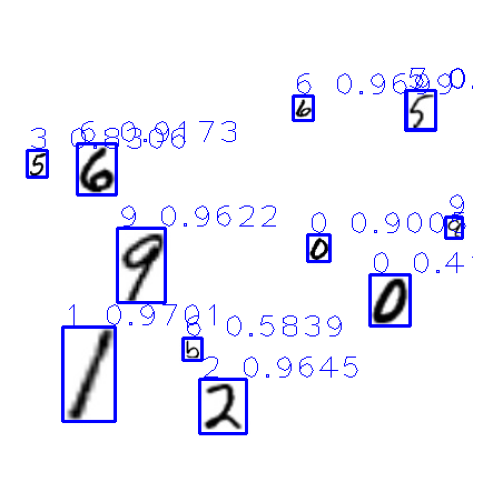

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

for box in result[0].boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().flatten().astype(int)
    cv2.rectangle(img, (x1,y1), (x2,y2), (0, 0, 255), 2)
    cv2.putText(img, f'{result[0].names[int(box.cls)]} {float(box.conf):.4f}', 
                (x1,y1), cv2.FONT_HERSHEY_PLAIN, 2, (0, 0, 255))

# Matplotlib으로 출력
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import cv2
img = cv2.imread('number.jpg')

for box in result[0].boxes:
    x1, y1, x2, y2 = box.xyxy[0].numpy().flatten().astype(int)
    cv2.rectangle(img, (x1,y1), (x2,y2), (0, 0, 255), 2)
    cv2.putText(img, f'{int(box.cls)} {float(box.conf):.4f}', (x1,y1), cv2.FONT_HERSHEY_PLAIN, 2, (0, 0, 255))

cv2.imshow('image', img)
cv2.waitKey()
cv2.destroyAllWindows()
